"""
DETECCIÓN DE ICTUS CON TRANSFER LEARNING
✔ DenseNet121 preentrenado en ImageNet
✔ Fine-tuning progresivo
✔ Optimizado para maximizar Recall de Stroke
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import precision_score, recall_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau"""

In [32]:
!pip install protobuf==5.26.1 --quiet
!pip install --upgrade --quiet tensorflow keras

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 5.26.1 which is incompatible.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.26.1 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 5.26.1 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 4

In [35]:
# ============================================================
# 1️⃣ CARGA Y PREPROCESAMIENTO DE DATOS
# ============================================================
X = np.load("/kaggle/input/imagenes/X_imagenes_procesadas.npy")
y_raw = np.load("/kaggle/input/imagenes/y_etiquetas.npy")

# Etiquetas binarias
y = np.array([1 if label != 'Normal' else 0 for label in y_raw])

# Split estratificado
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Añadir canal si falta
if X_train.ndim == 3:
    X_train = X_train[..., np.newaxis]
    X_val   = X_val[..., np.newaxis]
    X_test  = X_test[..., np.newaxis]

# Pesos de clases para balancear
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)





{0: 0.8064516129032258, 1: 1.3157894736842106}
Shapes:
Train: (2000, 224, 224, 1) (2000,)
Val: (250, 224, 224, 1) (250,)
Test: (251, 224, 224, 1) (251,)


In [36]:
# ============================================================
# 2️⃣ MODELO DENSE MEJORADO
# ============================================================
model = Sequential([
    Flatten(input_shape=X_train.shape[1:]),  # 224x224(+1)
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Precision(name='precision'), 
             tf.keras.metrics.Recall(name='recall')]
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
# ============================================================
# 3️⃣ CALLBACKS
# ============================================================
early_stop = EarlyStopping(monitor='val_recall', patience=5, mode='max', restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_recall', factor=0.5, patience=3, mode='max')

In [38]:
# ============================================================
# 3️⃣ ENTRENAMIENTO
# ============================================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)



Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 0.6682 - precision: 0.5460 - recall: 0.6868 - val_loss: 0.5551 - val_precision: 0.7632 - val_recall: 0.6105 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4538 - precision: 0.6919 - recall: 0.8066 - val_loss: 0.5613 - val_precision: 0.7000 - val_recall: 0.8105 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3279 - precision: 0.7605 - recall: 0.8816 - val_loss: 0.5234 - val_precision: 0.6276 - val_recall: 0.9579 - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2547 - precision: 0.8343 - recall: 0.9013 - val_loss: 0.5035 - val_precision: 0.6667 - val_recall: 0.8632 - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2001 - precision: 0.8636 - recall: 0.9329 - val_loss: 0.1871 - val_precision: 0.9247 - val_recall: 0.9053 - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/s

In [39]:
# ============================================================
# 4️⃣ EVALUACIÓN
# ============================================================
def eval_model(model, X, y, label):
    y_pred = (model.predict(X) > 0.5).astype(int)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    print(f"{label} - Precision: {precision:.4f}, Recall: {recall:.4f}")
    return precision, recall

p_train, r_train = eval_model(model, X_train, y_train, "Train")
p_val, r_val     = eval_model(model, X_val, y_val, "Validation")
p_test, r_test   = eval_model(model, X_test, y_test, "Test")

# Overfitting
loss_overfit = np.mean(history.history['loss'][-5:]) - np.mean(history.history['val_loss'][-5:])
recall_overfit = r_train - r_val
print(f"Overfitting - Pérdida: {loss_overfit*100:.2f}%")
print(f"Overfitting - Recall: {recall_overfit*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Train - Precision: 0.9450, Recall: 0.9947
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Validation - Precision: 0.8214, Recall: 0.9684
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Test - Precision: 0.7881, Recall: 0.9789
Overfitting - Pérdida: -11.09%
Overfitting - Recall: 2.63%


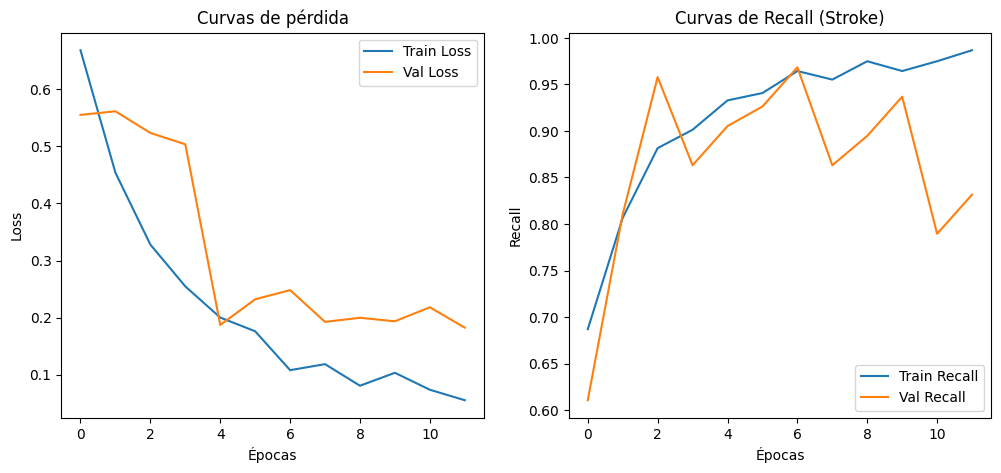

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


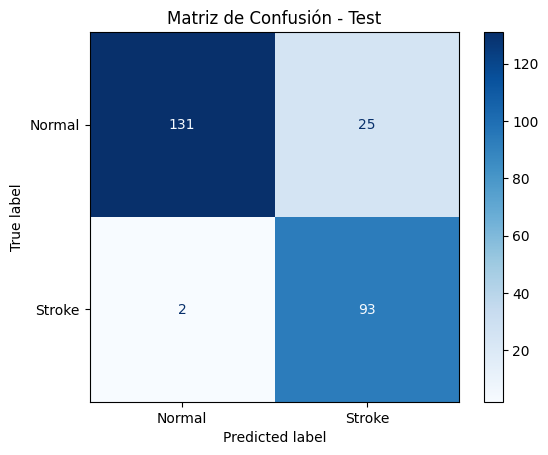

In [40]:
# ============================================================
# 📊 VISUALIZACIONES
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1️⃣ Curvas de entrenamiento: pérdida y recall
plt.figure(figsize=(12,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Curvas de pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Recall
plt.subplot(1,2,2)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Curvas de Recall (Stroke)')
plt.xlabel('Épocas')
plt.ylabel('Recall')
plt.legend()

plt.show()

# 2️⃣ Matriz de confusión en Test
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Stroke'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test")
plt.show()

